# Bootstrap Tail Overestimation Test

**Hypothesis:** The multinomial logistic regression overestimates tail category
probabilities (P(7), P(8), P(9+)), and these errors compound when aggregating
to bet-level probabilities like P(3+).

**Test:** Bootstrap resample the training data, refit the model N times, and compare
the bootstrap-averaged predictions against point estimates and actual outcomes.

**Success criteria (define BEFORE running):**
- Tail categories show higher coefficient of variation across bootstrap iterations
- Bootstrap-averaged aggregated probabilities have lower Brier scores than point estimates
- Overconfidence on extreme predictions is reduced

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import sqlite3
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
from nba.run import run_pipeline,data_pull,run_model

etl = NBAetl.etl()
data = NBAdata.data()
from betting import funcs
od = funcs.odds()


In [5]:
etl.showTables

,type,name,tbl_name,rootpage,sql
0,table,rosters,rosters,4,"CREATE TABLE rosters(\n teamId TEXT,\n s..."
1,table,players,players,2,"CREATE TABLE players(\n player_id TEXT,..."
2,table,teams,teams,6,"CREATE TABLE teams(\n team_id TEXT,\n te..."
3,table,plyrLogs,plyrLogs,123,"CREATE TABLE plyrLogs (player_id TEXT,\nteam_i..."
4,view,team_game,team_game,0,"CREATE VIEW team_game as \nSELECT season, game..."
5,table,shotsAllowed,shotsAllowed,582,"CREATE TABLE shotsAllowed (team_id TEXT,\ngame..."
6,view,roster_view,roster_view,0,"CREATE VIEW roster_view AS\nSELECT name, playe..."
7,table,oddsPoints,oddsPoints,761,"CREATE TABLE oddsPoints(\n name TEXT,\n ..."
8,table,oddsThrees,oddsThrees,18683,"CREATE TABLE oddsThrees(\n name TEXT,\n ..."
9,table,oddsFirstBasket,oddsFirstBasket,18685,"CREATE TABLE oddsFirstBasket(\n name TEXT,\..."


## Model Setup

In [4]:
# =============================================================
# CONFIG — UPDATE THESE
# =============================================================

N_BOOTSTRAPS = 200
RANDOM_SEED = 42
TEST_SIZE = 0.2

# UPDATE: your feature columns
FEATURE_COLS = [
    'cornerRatio',
 'abv_interaction',
 'crn_interaction',
 'mvAvgThrees',
 'daysBetweenGames',
 'wide_interaction',
 'home',
 'crn_fgaMv',
 'abv_fgaMv',
 'threes_residualsAllowedMv',
 'past3ThrPtPrct',
 'mvGood3Rate'
]

TARGET_COL = 'threesMade'


In [379]:
# =============================================================
# LOAD DATA — UPDATE CONNECTION AND QUERY
# =============================================================
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
etl = NBAetl.etl()
data = NBAdata.data()
threes = NBAmodels.models('threes')

td = data.threes_pipe(threes.data)

td = data.clean_na(td)

train = td[td.game_date.between('2022-10-01','2025-04-12')].filter(threes.features+['threesMade','name','game_date'])
train.dropna(inplace=True)

test = td[td.game_date.between('2025-10-01','2026-04-11')].filter(threes.features+['threesMade','name','game_date'])
test.dropna(inplace=True)


In [430]:
x_train_sm

,const,cornerRatio,abv_interaction,crn_interaction,mvAvgThrees,daysBetweenGames,wide_interaction,home,crn_fgaMv,abv_fgaMv,threes_residualsAllowedMv,past3ThrPtPrct,mvGood3Rate
69872,1.0,-0.514611,-1.232414,-1.329095,-1.224947,1.0,-1.607189,0.0,-0.407608,-0.181987,0.000000,0.255703,-1.373939
69873,1.0,-0.735198,-1.232414,-1.329095,1.588884,1.0,-0.208635,0.0,-0.848644,0.306841,0.000000,0.389723,-1.385895
69874,1.0,-0.005339,-1.232414,-1.329095,-0.287003,1.0,-0.937796,1.0,-0.221497,-0.730830,0.000000,0.462999,-1.474806
69875,1.0,0.824414,-1.232414,-1.329095,0.650941,1.0,-0.555285,1.0,-0.971802,1.168717,0.000000,0.229520,-1.447395
69876,1.0,-0.735198,-1.232414,-1.329095,0.650941,1.0,-0.705557,1.0,-1.012475,0.143271,0.000000,0.681274,-1.447395
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115891,1.0,0.824414,0.872779,-1.293532,0.025645,1.0,-0.064397,0.0,-1.338245,0.739385,-0.532429,-0.569502,-1.397386
115892,1.0,0.824414,0.199203,-1.327216,0.494617,1.0,1.285546,0.0,-1.377248,0.083115,0.157915,0.198354,-1.411914
115893,1.0,-0.761489,-0.178998,-0.707527,-0.130679,1.0,0.183655,0.0,-0.866189,-0.104461,-1.858900,0.952017,-1.429627
115894,1.0,0.824414,-0.718298,-1.312501,-0.912299,2.0,1.325391,0.0,-1.362490,-0.747210,-4.416887,0.567272,-1.456566


In [628]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
# =============================================================
# TRAIN/TEST SPLIT AND POINT ESTIMATE MODEL
# =============================================================

y_train = train.threesMade
y_test = test.threesMade

x_train = train.filter(threes.features)
x_test = test.filter(threes.features)

x_train_scaled = threes.standRobust_scaler(x_train)
x_test_scaled = threes.standRobust_scaler(x_test)


x_train_rescaled = pd.DataFrame(data = ss.fit_transform(x_train),columns = x_train.columns.values)
x_test_rescaled = pd.DataFrame(data = ss.transform(x_test),columns = x_test.columns.values)

x_train_rescaled['home'] = x_train.home.values
x_train_rescaled['cornerRatio'] = x_train.cornerRatio.values
x_test_rescaled['home'] = x_test.home.values
x_test_rescaled['cornerRatio']= x_test.cornerRatio.values

print('Train: {:,}, Test: {:,}'.format(len(x_train), len(x_test)))

Train: 69,454, Test: 23,173


In [624]:
x_train.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
cornerRatio,69454.0,-0.045,0.629,-0.761,-0.515,-0.137,0.375,1.270
abv_interaction,69454.0,-0.016,1.089,-1.232,-0.870,-0.262,0.558,6.965
crn_interaction,69454.0,-0.014,1.269,-1.329,-1.015,-0.312,0.612,11.460
mvAvgThrees,69454.0,-0.018,0.999,-1.225,-0.756,-0.131,0.651,5.653
daysBetweenGames,69454.0,1.634,1.968,0.000,1.000,1.000,2.000,10.000
wide_interaction,69454.0,0.198,0.856,-1.607,-0.249,0.187,0.644,8.147
home,69454.0,0.501,0.500,0.000,0.000,1.000,1.000,1.000
crn_fgaMv,69454.0,-0.007,1.224,-1.380,-1.014,-0.265,0.675,8.373
abv_fgaMv,69454.0,-0.008,1.068,-1.248,-0.853,-0.241,0.587,6.082
threes_residualsAllowedMv,69454.0,-0.044,2.257,-8.950,-1.500,0.000,1.497,9.083


In [623]:
x_train_rescaled.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
cornerRatio,69454.0,-0.000,1.0,-1.140,-0.747,-0.147,0.668,2.092
abv_interaction,69454.0,0.000,1.0,-1.117,-0.784,-0.227,0.526,6.408
crn_interaction,69454.0,-0.000,1.0,-1.037,-0.789,-0.235,0.493,9.043
mvAvgThrees,69454.0,-0.000,1.0,-1.209,-0.740,-0.113,0.669,5.679
daysBetweenGames,69454.0,-0.000,1.0,-0.831,-0.322,-0.322,0.186,4.251
wide_interaction,69454.0,-0.000,1.0,-2.110,-0.523,-0.013,0.521,9.287
home,69454.0,0.501,0.5,0.000,0.000,1.000,1.000,1.000
crn_fgaMv,69454.0,-0.000,1.0,-1.121,-0.822,-0.211,0.557,6.845
abv_fgaMv,69454.0,0.000,1.0,-1.161,-0.791,-0.218,0.557,5.703
threes_residualsAllowedMv,69454.0,-0.000,1.0,-3.946,-0.645,0.019,0.683,4.043


In [7]:
# fit point estimate model

three_probs = threes.model.predict(x_test_sm)



## Bootstrap Function

In [8]:
def fit_bootstrap_model(X_train_sm, y_train, X_test_sm):
    """
    Single bootstrap iteration: resample training data,
    fit MNLogit, return predicted probabilities and classes.
    """
    n = len(X_train_sm)
    idx = np.random.choice(n, size=n, replace=True)
    
    X_boot = X_train_sm.iloc[idx].reset_index(drop=True)
    y_boot = y_train.iloc[idx].reset_index(drop=True)
    
    model = sm.MNLogit(y_boot, X_boot)
    results = model.fit(disp=0, maxiter=200)
    
    probs = results.predict(X_test_sm)
    classes = np.array(sorted(y_boot.unique()))
    
    return probs, classes

In [75]:
probs_full = threes.model.predict(x_test_sm)
np.random.seed(521)
n_boots = 10_000
boot_agg_store = {t: np.zeros((n_boots, n_test)) for t in AGGREGATION_THRESHOLDS}

for i in range(n_boots):
    idx = np.random.choice(n_test, size=n_test, replace=True)
    boot_probs = point_prob_arr[idx]
    for t in AGGREGATION_THRESHOLDS:
        mask = point_classes >= t
        boot_agg_store[t][i] = boot_probs[:, mask].sum(axis=1)

    if (i + 1) % 1000 == 0:
        print('Completed {}/{}'.format(i + 1, n_boots))

Completed 1000/10000
Completed 2000/10000
Completed 3000/10000
Completed 4000/10000
Completed 5000/10000
Completed 6000/10000
Completed 7000/10000
Completed 8000/10000
Completed 9000/10000
Completed 10000/10000


## Bootstrap Results Analysis

### Test 1: Category Drop Rate
How often does the bootstrap lose a category entirely? High drop rate = not enough data to support that category.

In [10]:
point_classes = [0,1,2,3,4,5,6,7,8,9]
missing = Counter()
for classes in all_classes:
    unique_classes = set(classes)
    for c in point_classes:
        if c not in unique_classes:
            missing[c] += 1
            
n_success = len(all_classes)

print('Category Drop Rate Across {} Bootstrap Iterations'.format(n_success))
print('=' * 50)
for c in sorted(point_classes):
    ct = missing.get(c, 0)
    print('Category {:>3}: dropped {} times ({:.1f}%)'.format(
        c, ct, ct / n_success * 100))

# flag categories for potential collapse
collapse_threshold = 0.05
flagged = [c for c in point_classes if missing.get(c, 0) / n_success > collapse_threshold]
if flagged:
    print('\n>> Categories to consider collapsing (>{:.0f}% drop rate): {}'.format(
        collapse_threshold * 100, flagged))
else:
    print('\n>> All categories stable across bootstrap iterations')

Category Drop Rate Across 10000 Bootstrap Iterations
Category   0: dropped 0 times (0.0%)
Category   1: dropped 0 times (0.0%)
Category   2: dropped 0 times (0.0%)
Category   3: dropped 0 times (0.0%)
Category   4: dropped 0 times (0.0%)
Category   5: dropped 0 times (0.0%)
Category   6: dropped 0 times (0.0%)
Category   7: dropped 0 times (0.0%)
Category   8: dropped 0 times (0.0%)
Category   9: dropped 0 times (0.0%)

>> All categories stable across bootstrap iterations


### Test 2: Per-Category Uncertainty
Coefficient of variation for each outcome category. Tail categories should show higher CoV.

In [77]:
point_prob_arr = probs_full.values if hasattr(probs_full, 'values') else probs_full
n_test = len(point_prob_arr)
point_classes = np.array(probs_full.columns)
AGGREGATION_THRESHOLDS = [2, 3, 4, 5,6,7,8,9]

# Test 2 computed directly from probs_full - no bootstrap needed for fixed model
category_stats = []
for j, c in enumerate(point_classes):
    mean_prob = point_prob_arr[:, j].mean()
    std_prob = point_prob_arr[:, j].std()
    cov = std_prob / mean_prob if mean_prob > 1e-6 else np.inf
    category_stats.append({'category': c, 'mean_prob': mean_prob, 'boot_std': std_prob, 'cov': cov})

cat_df = pd.DataFrame(category_stats)
print(cat_df.to_string(index=False))

# store only aggregated probs per threshold across bootstrap iterations
np.random.seed(521)
n_boots = 10_000
boot_agg_store = {t: np.zeros((n_boots, n_test)) for t in AGGREGATION_THRESHOLDS}

for i in range(n_boots):
    idx = np.random.choice(n_test, size=n_test, replace=True)
    boot_probs = point_prob_arr[idx]
    for t in AGGREGATION_THRESHOLDS:
        mask = point_classes >= t
        boot_agg_store[t][i] = boot_probs[:, mask].sum(axis=1)

    if (i + 1) % 1000 == 0:
        print('Completed {}/{}'.format(i + 1, n_boots))

 category  mean_prob  boot_std      cov
        0   0.397830  0.267816 0.673193
        1   0.239526  0.077920 0.325311
        2   0.162407  0.076776 0.472739
        3   0.100879  0.074632 0.739822
        4   0.051382  0.051177 0.996004
        5   0.027299  0.037031 1.356505
        6   0.011491  0.018558 1.614982
        7   0.006259  0.011825 1.889261
        8   0.001987  0.004528 2.278455
        9   0.000940  0.003151 3.350389
Completed 1000/10000
Completed 2000/10000
Completed 3000/10000
Completed 4000/10000
Completed 5000/10000
Completed 6000/10000
Completed 7000/10000
Completed 8000/10000
Completed 9000/10000
Completed 10000/10000


In [16]:
# compute per-category stats
category_stats = []
for j, c in enumerate(point_classes):
    mean_prob = point_prob_arr[:, j].mean()
    std_prob = point_prob_arr[:, j].std()
    cov = std_prob / mean_prob if mean_prob > 1e-6 else np.inf
    category_stats.append({
        'category': c,
        'mean_prob': mean_prob,
        'boot_std': std_prob,
        'cov': cov
    })

cat_df = pd.DataFrame(category_stats)
print(cat_df.to_string(index=False))

 category  mean_prob  boot_std      cov
        0   0.397830  0.267816 0.673193
        1   0.239526  0.077920 0.325311
        2   0.162407  0.076776 0.472739
        3   0.100879  0.074632 0.739822
        4   0.051382  0.051177 0.996004
        5   0.027299  0.037031 1.356505
        6   0.011491  0.018558 1.614982
        7   0.006259  0.011825 1.889261
        8   0.001987  0.004528 2.278455
        9   0.000940  0.003151 3.350389


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


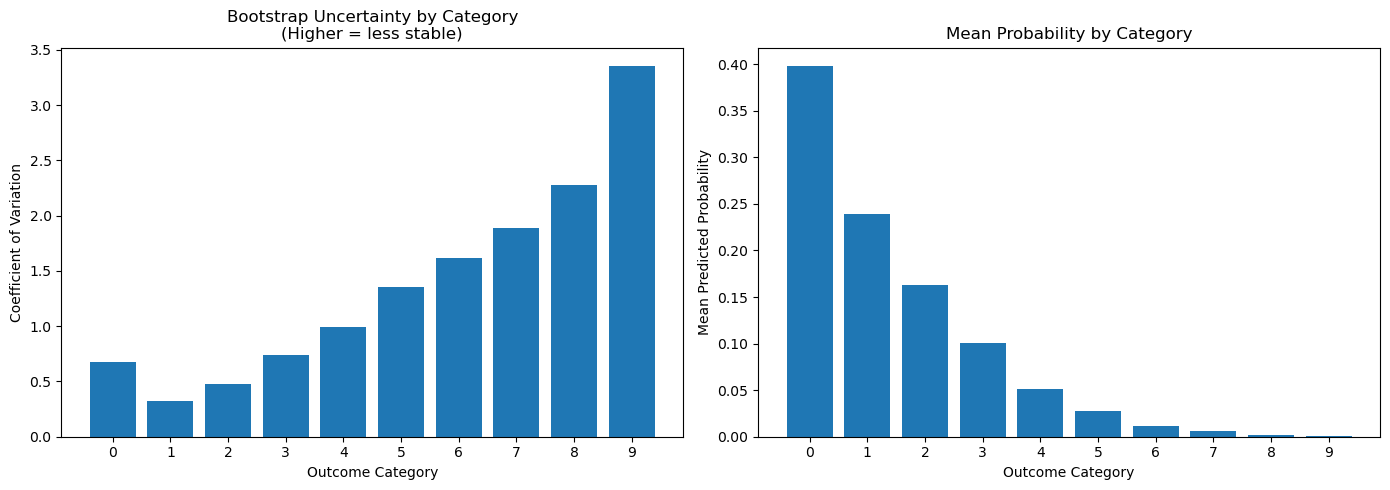

In [17]:
# plot: CoV by category
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cat_df['category'].astype(str), cat_df['cov'])
axes[0].set_xlabel('Outcome Category')
axes[0].set_ylabel('Coefficient of Variation')
axes[0].set_title('Bootstrap Uncertainty by Category\n(Higher = less stable)')

axes[1].bar(cat_df['category'].astype(str), cat_df['mean_prob'])
axes[1].set_xlabel('Outcome Category')
axes[1].set_ylabel('Mean Predicted Probability')
axes[1].set_title('Mean Probability by Category')

plt.tight_layout()
plt.show()

### Test 3: Aggregated Bet Probabilities — Point vs Bootstrap
Compare calibration at each betting threshold.

In [471]:
def readable_cov(model, top_n=100):
    se = np.sqrt(np.diag(model.cov_params()))
    params = model.params
    summary = []
    for i, name in enumerate(model.cov_params().columns):
        summary.append({
            'outcome': name[0],
            'parameter': name[1],
            'coefficient': params.values.flatten()[i],
            'std_error': se[i],
            'z_score': params.values.flatten()[i] / se[i]
        })
    df = pd.DataFrame(summary)
    df['abs_z'] = df.z_score.abs()
    return df

covdf = readable_cov(threes.model, top_n=1000)

In [475]:
upModel.cov_params()

array([[ 3.74630666e-01,  7.02062228e-05, -7.02528399e-04, ...,
         4.72122008e-05,  1.66410647e-04,  1.46244485e-01],
       [ 7.02062228e-05,  3.59352597e-04, -3.67899707e-06, ...,
        -3.67169518e-08,  7.90978270e-06,  1.33104674e-05],
       [-7.02528399e-04, -3.67899707e-06,  1.91591610e-03, ...,
         2.02488748e-05,  4.11742344e-06, -3.14266912e-04],
       ...,
       [ 4.72122008e-05, -3.67169518e-08,  2.02488748e-05, ...,
         4.35134453e-04, -2.02668247e-05,  4.53869641e-04],
       [ 1.66410647e-04,  7.90978270e-06,  4.11742344e-06, ...,
        -2.02668247e-05,  8.03864812e-03,  1.23504547e-02],
       [ 1.46244485e-01,  1.33104674e-05, -3.14266912e-04, ...,
         4.53869641e-04,  1.23504547e-02,  3.61416048e+00]])

In [382]:
covdf[covdf.parameter.isin(['abv_fgaMv','abv_interaction'])]

,outcome,parameter,coefficient,std_error,z_score,abs_z
2,1,abv_interaction,-1.526879,0.100603,-15.177319,15.177319
9,1,abv_fgaMv,-0.273686,0.102843,-2.661195,2.661195
15,2,abv_interaction,-0.359284,0.104440,-3.440097,3.440097
22,2,abv_fgaMv,0.283749,0.107707,2.634455,2.634455
28,3,abv_interaction,0.106855,0.112714,0.948013,0.948013
35,3,abv_fgaMv,-0.096449,0.117706,-0.819406,0.819406
41,4,abv_interaction,0.389598,0.125867,3.095329,3.095329
48,4,abv_fgaMv,-0.050276,0.132923,-0.378235,0.378235
54,5,abv_interaction,0.138607,0.146209,0.948005,0.948005
61,5,abv_fgaMv,-0.067215,0.156905,-0.428383,0.428383


In [195]:
covdf.groupby(['outcome'])[['coefficient','std_error','z_score','abs_z']].mean()

,coefficient,std_error,z_score,abs_z
outcome,,,,
1,-2.611337,0.033800,-160.748377,160.748377
2,0.005659,0.037580,5.963719,17.577325
3,0.266506,0.044143,11.392176,11.518239
4,0.192954,0.053932,7.551006,9.820879
5,0.034803,0.070015,0.974208,1.737956
6,0.243648,0.097803,3.612826,3.612826
7,0.761533,0.137287,7.286900,7.305795
8,0.085005,0.221203,0.724569,1.335064
9,0.291920,0.278585,0.861100,0.919278


In [205]:
train.threesMade.value_counts(normalize=True).sort_values().cumsum() * 100

threesMade
13      0.002187
12      0.008749
11      0.019685
10      0.050306
9       0.118110
8       0.312773
7       0.811461
6       1.900700
5       4.420385
4       9.232283
3      18.258968
2      34.466317
1      58.799213
0     100.000000
Name: proportion, dtype: float64

In [206]:
test.threesMade.value_counts(normalize=True).sort_values().cumsum() * 100

threesMade
11      0.004262
12      0.008524
10      0.038360
9       0.110817
8       0.315404
7       0.814082
6       1.998977
5       4.556304
4       9.943739
3      20.087802
2      35.879294
1      59.615549
0     100.000000
Name: proportion, dtype: float64

---Retrain

In [315]:
import statsmodels.api as sm

In [384]:
threes.brier_scores([x if x<10 else 9 for x in y_test],threes.model.predict(sm.add_constant(x_test_scaled.filter(threes.features))))


brier score of:  0.665


0.6653604613296171

In [ ]:
readable_cov(up
             

In [385]:
preds = threes.model.predict(sm.add_constant(x_test.filter(threes.features))).mean()

In [386]:
actuals = pd.Series([x if x<10 else 9 for x in y_test]).value_counts(normalize=True).sort_index()

In [387]:
comps = pd.DataFrame({'actuals':actuals,'preds':preds})

In [401]:
comps['diff'] = comps.actuals - comps.preds
comps['cumulativeDiff'] = (comps.sort_index(ascending=False).cumsum().actuals - comps.sort_index(ascending=False).cumsum().preds).round(5).sort_index()

In [402]:
comps

,actuals,preds,diff,cumulativeDiff
0,0.399215,0.391683,0.007532,0.00000
1,0.245113,0.244660,0.000453,-0.00753
2,0.164157,0.165274,-0.001118,-0.00799
3,0.096233,0.101408,-0.005175,-0.00687
4,0.052604,0.050861,0.001743,-0.00169
5,0.025288,0.026547,-0.001259,-0.00344
6,0.010486,0.010922,-0.000436,-0.00218
7,0.004056,0.005958,-0.001901,-0.00174
8,0.001683,0.001845,-0.000162,0.00016
9,0.001165,0.000843,0.000322,0.00032


In [419]:
def brier_summary(probs, y, thresholds=[2,3,4,5]):
    """
    Brier score overall and by threshold.
    probs: DataFrame of predicted probabilities (n_obs x n_classes)
    y: Series of actual outcomes
    """
    point_classes = np.array(probs.columns)
    y_arr = y.values if hasattr(y, 'values') else y
    prob_arr = probs.values if hasattr(probs, 'values') else probs

    results = []
    for threshold in thresholds:
        mask = point_classes >= threshold
        pred_agg = prob_arr[:, mask].sum(axis=1)
        actual = (y_arr >= threshold).astype(float)
        brier = ((pred_agg - actual) ** 2).mean()
        results.append({
            'threshold': '{}+'.format(threshold),
            'actual_rate': actual.mean(),
            'pred_rate': pred_agg.mean(),
            'overconfidence': pred_agg.mean() - actual.mean(),
            'brier_score': brier
        })

    df_out = pd.DataFrame(results)
    print('Brier Score Summary')
    print('=' * 60)
    print(df_out.to_string(index=False))
    return df_out


def residual_bias(probs, y, df, threshold=3):
    """
    Checks for systematic bias in residuals by probability decile,
    month, and cornerRatio bucket.
    probs: DataFrame of predicted probabilities
    y: Series of actual outcomes
    df: full player DataFrame containing game_date and cornerRatio
    """
    point_classes = np.array(probs.columns)
    y_arr = y.values if hasattr(y, 'values') else y
    prob_arr = probs.values if hasattr(probs, 'values') else probs

    mask = point_classes >= threshold
    pred_agg = prob_arr[:, mask].sum(axis=1)
    actual = (y_arr >= threshold).astype(float)
    residuals = pred_agg - actual

    results = df[['game_date', 'cornerRatio']].copy().reset_index(drop=True)
    results['pred'] = pred_agg
    results['actual'] = actual
    results['residual'] = residuals
    results['prob_decile'] = pd.qcut(pred_agg, 10, labels=False, duplicates='drop')
    results['month'] = pd.to_datetime(results['game_date']).dt.month

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # by probability decile
    decile_bias = results.groupby('prob_decile')['residual'].mean()
    axes[0].bar(decile_bias.index, decile_bias.values)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel('Probability Decile')
    axes[0].set_ylabel('Mean Residual')
    axes[0].set_title('Residual Bias by Probability Decile\nP({}+)'.format(threshold))

    # by month
    month_bias = results.groupby('month')['residual'].mean()
    axes[1].bar(month_bias.index, month_bias.values)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Mean Residual')
    axes[1].set_title('Residual Bias by Month\nP({}+)'.format(threshold))

    # by cornerRatio bucket
    cr_bias = results.groupby('cornerRatio')['residual'].mean()
    axes[2].bar(range(len(cr_bias)), cr_bias.values)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_xticks(range(len(cr_bias)))
    axes[2].set_xticklabels(['{:.2f}'.format(x) for x in cr_bias.index], rotation=45)
    axes[2].set_xlabel('cornerRatio Bucket')
    axes[2].set_ylabel('Mean Residual')
    axes[2].set_title('Residual Bias by cornerRatio\nP({}+)'.format(threshold))

    plt.tight_layout()
    plt.show()
    return results


def feature_describe(df, feature_cols, target_col='threesMade'):
    """
    Describe statistics for each feature grouped by outcome class.
    """
    for col in feature_cols:
        print('\n{}'.format(col))
        print('-' * 60)
        print(df.groupby(target_col)[col].describe().round(4).to_string())


def feature_distributions(df, feature_cols, target_col='threesMade'):
    """
    Distribution plots for each feature, overlaid by outcome class.
    """
    classes = sorted(df[target_col].unique())
    n_cols = len(feature_cols)
    n_rows = -(-len(feature_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        for cls in classes:
            subset = df[df[target_col] == cls][col].dropna()
            axes[i].hist(subset, bins=30, alpha=0.3, label='class {}'.format(cls), density=True)
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right')
    plt.suptitle('Feature Distributions by Outcome Class', y=1.01)
    plt.tight_layout()
    plt.show()


def feature_boxplots(df, feature_cols, target_col='threesMade',bin=None):
    """
    Boxplots of mean feature value aggregated by outcome class.
    """
    df.threesMade = df.threesMade.astype(int) if bin==None else [int(x) if x<bin else bin for x in df.threesMade]
    agg = df.groupby(target_col)[feature_cols].mean()
    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        axes[i].bar(agg.index.astype(str), agg[col].values)
        axes[i].set_title(col)
        axes[i].set_xlabel('threesMade')
        axes[i].set_ylabel('Mean {}'.format(col))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Mean Feature Value by Outcome Class', y=1.01)
    plt.tight_layout()
    axes[i].set_xticks(range(len(agg.index)))
    axes[i].set_xticklabels(agg.index.astype(str), rotation=45, fontsize=8)
    plt.show()


def feature_joint(df, feature_cols, target_col='threesMade'):
    """
    Aggregated joint plots: mean feature vs mean outcome per cornerRatio bucket.
    """
    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    agg = df.groupby('cornerRatio').agg(
        mean_outcome=(target_col, 'mean'),
        **{'mean_{}'.format(col): (col, 'mean') for col in feature_cols}
    ).reset_index()

    for i, col in enumerate(feature_cols):
        axes[i].scatter(agg['mean_{}'.format(col)], agg['mean_outcome'], alpha=0.7)
        axes[i].set_xlabel('Mean {}'.format(col))
        axes[i].set_ylabel('Mean {}'.format(target_col))
        axes[i].set_title('{} vs {}'.format(col, target_col))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Aggregated Joint: Mean Feature vs Mean Outcome by cornerRatio Bucket', y=1.01)
    plt.tight_layout()
    plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

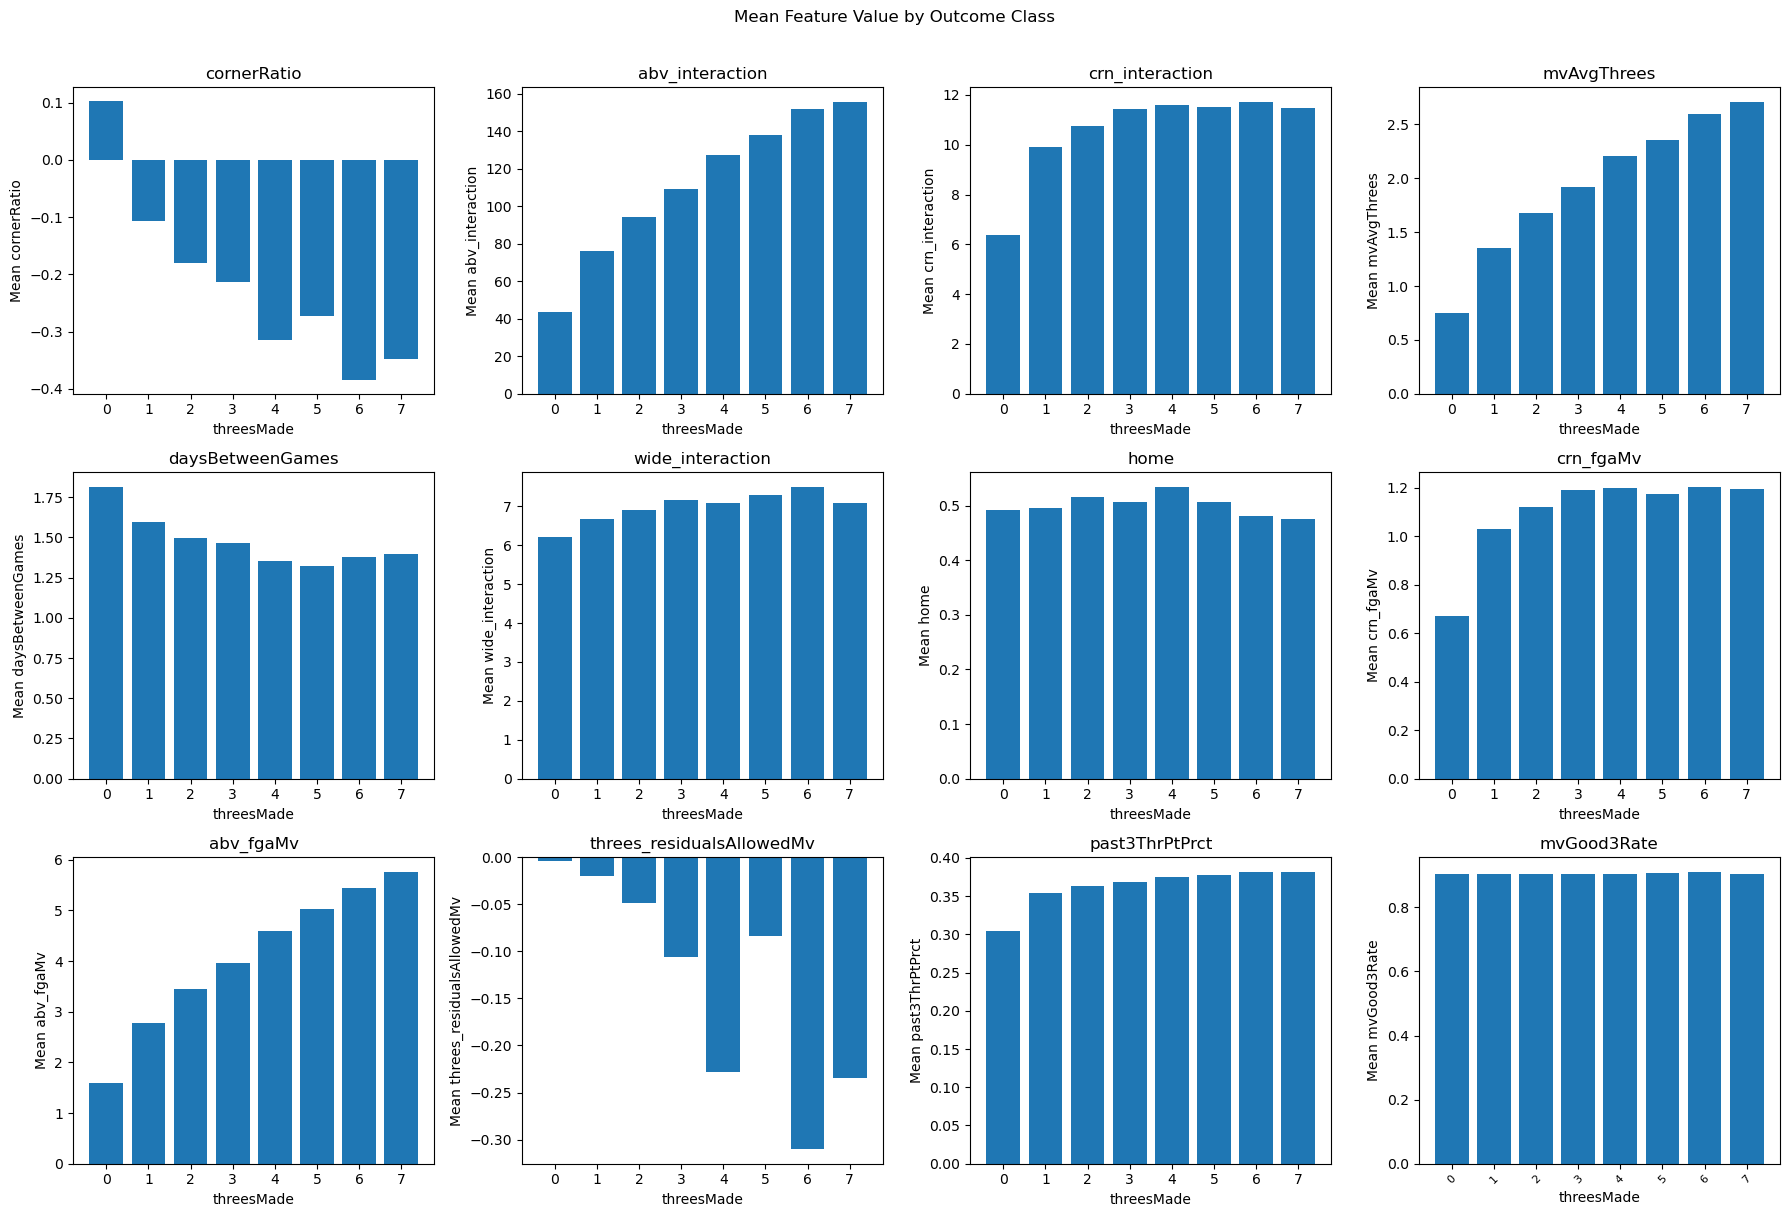

In [487]:
feature_boxplots(test.filter(threes.features[1:]+['threesMade']),threes.features[1:],bin=7)

In [421]:
y7cap = [x if x < 7 else 7 for x in y_train ]

In [480]:
newMod = sm.MNLogit(endog = np.array(y7cap), exog = sm.add_constant(x_train_scaled.filter(threes.features),))
upModel = newMod.fit(method = 'bfgs',maxiter=1000)
p = upModel.predict(sm.add_constant(x_test_scaled.filter(threes.features)))

Optimization terminated successfully.
         Current function value: 1.356632
         Iterations: 512
         Function evaluations: 513
         Gradient evaluations: 513


In [481]:
threes.brier_scores(actualsBin7,p)

brier score of:  0.659


0.6585032693229181

In [492]:
readable_cov(upModel)[readable_cov(upModel).outcome=='7']

,outcome,parameter,coefficient,std_error,z_score,abs_z
78,7,const,0.285075,2.715158,0.104994,0.104994
79,7,cornerRatio,0.394858,0.081981,4.816465,4.816465
80,7,abv_interaction,0.488013,0.101080,4.828006,4.828006
81,7,crn_interaction,0.569978,0.083496,6.826376,6.826376
82,7,mvAvgThrees,0.609643,0.063503,9.600275,9.600275
83,7,daysBetweenGames,0.852249,0.032250,26.426050,26.426050
84,7,wide_interaction,0.122573,0.096154,1.274748,1.274748
85,7,home,1.237579,0.088050,14.055431,14.055431
86,7,crn_fgaMv,2.458839,0.092171,26.676839,26.676839
87,7,abv_fgaMv,2.469501,0.115218,21.433220,21.433220


<Axes: >

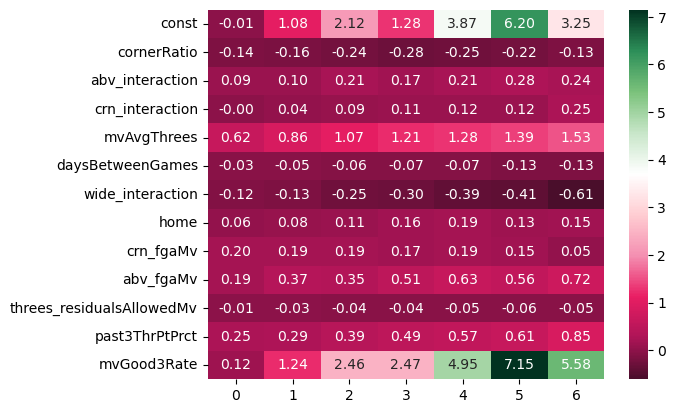

In [516]:
sns.heatmap(upModel.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

In [ ]:
feature_boxplots(test.filter(threes.features[1:]+['threesMade']),threes.features[1:],bin=8)

In [462]:
pd.DataFrame({'actuals': pd.Series(actualsBin7).value_counts(normalize=True), 'preds':p.mean()})

,actuals,preds
0,0.399215,0.398488
1,0.245113,0.242471
2,0.164157,0.164640
3,0.096233,0.097590
4,0.052604,0.051209
5,0.025288,0.025898
6,0.010486,0.011650
7,0.006905,0.008054


In [454]:
actualsBin7 = [x if x < 7 else 7 for x in y_test]

In [456]:
pd.DataFrame(actualsBin7).value_counts(normalize=True)

0    0.399215
1    0.245113
2    0.164157
3    0.096233
4    0.052604
5    0.025288
6    0.010486
7    0.006905
Name: proportion, dtype: float64

In [447]:
actuals

0    0.399215
1    0.245113
2    0.164157
3    0.096233
4    0.052604
5    0.025288
6    0.010486
7    0.004056
8    0.001683
9    0.001165
Name: proportion, dtype: float64

In [444]:
comps['diff']

0    0.007532
1    0.000453
2   -0.001118
3   -0.005175
4    0.001743
5   -0.001259
6   -0.000436
7   -0.001901
8   -0.000162
9    0.000322
Name: diff, dtype: float64

In [518]:
#checking multi-colinearity between the interaction and the shots
drops = ['crn_fgaMv','abv_fgaMv',]
newCols = [x for x in threes.features if x not in drops] 

In [519]:
multMod = sm.MNLogit(endog = np.array(y7cap), exog = sm.add_constant(x_train_scaled.filter(newCols),))
multModFit = multMod.fit(method = 'bfgs',maxiter=1000)
p = multModFit.predict(sm.add_constant(x_test_scaled.filter(newCols)))

Optimization terminated successfully.
         Current function value: 1.358316
         Iterations: 432
         Function evaluations: 433
         Gradient evaluations: 433


<Axes: >

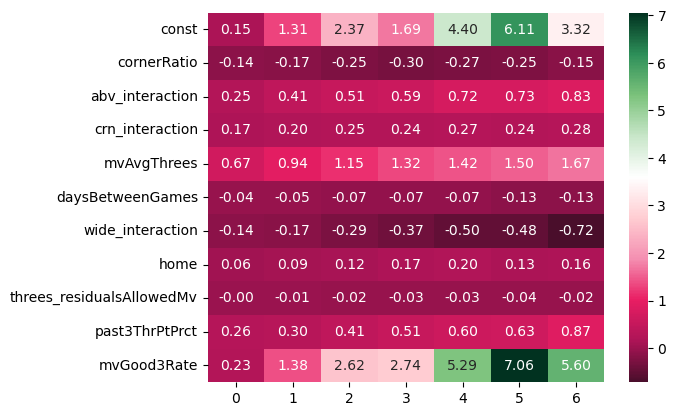

In [521]:
sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

In [524]:
readable_cov(multModFit)[readable_cov(multModFit).parameter.isin(['abv_interaction','crn_interaction'])]

,outcome,parameter,coefficient,std_error,z_score,abs_z
2,1,abv_interaction,2.369428,0.017673,134.069348,134.069348
3,1,crn_interaction,1.687217,0.009758,172.907295,172.907295
13,2,abv_interaction,-0.152292,0.018910,-8.053504,8.053504
14,2,crn_interaction,0.250275,0.010833,23.103241,23.103241
24,3,abv_interaction,0.244541,0.021202,11.533918,11.533918
25,3,crn_interaction,0.269157,0.012583,21.390540,21.390540
35,4,abv_interaction,-0.035149,0.024732,-1.421195,1.421195
36,4,crn_interaction,-0.047341,0.015630,-3.028753,3.028753
46,5,abv_interaction,-0.495121,0.029879,-16.570594,16.570594
47,5,crn_interaction,-0.484711,0.020053,-24.171583,24.171583


In [531]:
x_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
cornerRatio,69454.0,-0.044796,0.628558,-0.761489,-0.514611,-0.137328,0.375155,1.269843
abv_interaction,69454.0,-0.015517,1.089390,-1.232414,-0.869940,-0.262444,0.557721,6.965496
crn_interaction,69454.0,-0.013668,1.268712,-1.329095,-1.015069,-0.312288,0.611554,11.459672
mvAvgThrees,69454.0,-0.017523,0.998567,-1.224947,-0.755975,-0.130679,0.650941,5.653307
daysBetweenGames,69454.0,1.634449,1.967879,0.000000,1.000000,1.000000,2.000000,10.000000
wide_interaction,69454.0,0.198444,0.855907,-1.607189,-0.249277,0.186978,0.644044,8.146828
home,69454.0,0.501325,0.500002,0.000000,0.000000,1.000000,1.000000,1.000000
crn_fgaMv,69454.0,-0.007145,1.224334,-1.379654,-1.013587,-0.264908,0.675164,8.373206
abv_fgaMv,69454.0,-0.008232,1.067775,-1.248198,-0.853312,-0.241325,0.586950,6.081673
threes_residualsAllowedMv,69454.0,-0.043876,2.257245,-8.949811,-1.500214,0.000000,1.497351,9.082773


In [525]:
intdrops = ['abv_interaction','crn_interaction',]
newColsInt = [x for x in threes.features if x not in intdrops] 
multMod = sm.MNLogit(endog = np.array(y7cap), exog = sm.add_constant(x_train_scaled.filter(newColsInt),))
multModFit = multMod.fit(method = 'bfgs',maxiter=1000)
p = multModFit.predict(sm.add_constant(x_test_scaled.filter(newColsInt)))
threes.brier_scores(actualsBin7,p)
sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

Optimization terminated successfully.
         Current function value: 1.357051
         Iterations: 427
         Function evaluations: 428
         Gradient evaluations: 428


In [526]:
threes.brier_scores(actualsBin7,p)

brier score of:  0.659


0.6586481269400264

<Axes: >

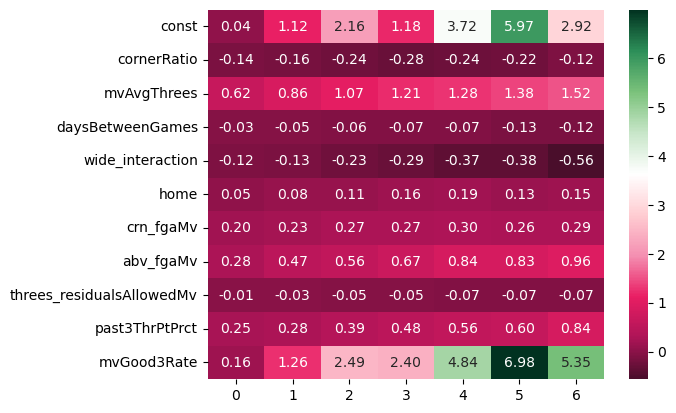

In [527]:
sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

In [529]:
readable_cov(multModFit)[readable_cov(multModFit).parameter.isin(['abv_fgaMv','crn_fgaMv'])]

,outcome,parameter,coefficient,std_error,z_score,abs_z
6,1,crn_fgaMv,2.920220,0.010174,287.029096,287.029096
7,1,abv_fgaMv,-0.138192,0.018814,-7.345192,7.345192
17,2,crn_fgaMv,1.212247,0.011381,106.512310,106.512310
18,2,abv_fgaMv,1.278764,0.020285,63.039778,63.039778
28,3,crn_fgaMv,-0.121080,0.013384,-9.046564,9.046564
29,3,abv_fgaMv,-0.131620,0.023041,-5.712379,5.712379
39,4,crn_fgaMv,0.188578,0.016697,11.293987,11.293987
40,4,abv_fgaMv,0.128595,0.027194,4.728835,4.728835
50,5,crn_fgaMv,0.468779,0.021540,21.763423,21.763423
51,5,abv_fgaMv,0.563731,0.033392,16.882459,16.882459


In [535]:
train.mvGood3Rate.describe()

count    69454.000000
mean         0.894080
std          0.037629
min          0.665306
25%          0.873171
50%          0.897872
75%          0.918798
max          1.098039
Name: mvGood3Rate, dtype: float64

In [536]:
x_train.mvGood3Rate.describe()

count    69454.000000
mean        -1.427623
std          0.024438
min         -1.576197
25%         -1.441203
50%         -1.425161
75%         -1.411571
max         -1.295166
Name: mvGood3Rate, dtype: float64

In [1]:
def mod_run(intdrops):
    
    newColsInt = [x for x in threes.features if x not in intdrops] 
    multMod = sm.MNLogit(endog = np.array(y7cap), exog = sm.add_constant(x_train_rescaled.filter(newColsInt),))
    multModFit = multMod.fit(method = 'bfgs',maxiter=1000)
    p = multModFit.predict(sm.add_constant(x_test_rescaled.filter(newColsInt)))
    print(threes.brier_scores(actualsBin7,p))
    y_test_bin = label_binarize(y_test.clip(upper=7), classes=sorted(y_test.clip(upper=7).unique()))
    model_brier = ((p.values - y_test_bin) ** 2).mean()
    null_brier = ((null_probs - y_test_bin) ** 2).mean()
    skill_score = 1 - (model_brier / null_brier)
    print('Model Brier: {:.4f}'.format(model_brier))
    print('Null Brier: {:.4f}'.format(null_brier))
    print('Skill score: {:.4f}'.format(skill_score))
    sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)
    plt.show()

In [2]:
mod_run(['crn_fgaMv','abv_fgaMv'])

NameError: name 'threes' is not defined

In [640]:
mcopt = optb.MulticlassOptimalBinning('cornerRatio',min_prebin_size=.05)

In [662]:
raw_ratio = x_train.abv_fgaMv / (x_train.abv_fgaMv + x_train.crn_fgaMv)
mcopt.fit(raw_ratio.values,y_train.clip(upper=7).values)

MulticlassOptimalBinning(name='cornerRatio')

In [663]:
mcopt.binning_table.build().T

,0,1,2,3,4,5,6,7,Totals
Bin,"(-inf, 0.42)","[0.42, 0.47)","[0.47, 0.48)","[0.48, 0.53)","[0.53, 0.71)","[0.71, inf)",Special,Missing,
Count,29059,4123,6105,4013,7223,18931,0,0,69454
Count (%),0.418392,0.059363,0.0879,0.057779,0.103997,0.272569,0.0,0.0,1.0
Event_0,9742,2361,5652,2201,3032,5435,0,0,28423
Event_1,8364,885,262,858,1757,4641,0,0,16767
Event_2,5489,460,102,444,1062,3602,0,0,11159
Event_3,3048,221,54,234,623,2350,0,0,6530
Event_4,1390,106,18,158,368,1438,0,0,3478
Event_5,619,54,15,70,216,781,0,0,1755
Event_6,254,15,1,27,94,389,0,0,780


In [664]:
print(mcopt.transform(raw_ratio.values[:5], metric='mean_woe'))
print(mcopt.transform(raw_ratio.values[:5], metric='indices'))

[ 0.08370142  0.08370142 -0.27777333 -0.27777333  0.08370142]
[0 0 5 5 0]


In [668]:
x_train_rescaled['cornerRatio'] = mcopt.transform(raw_ratio.values, metric='mean_woe')
test_raw_ratio = x_test.abv_fgaMv / (x_test.abv_fgaMv + x_test.crn_fgaMv)
x_test_rescaled['cornerRatio'] = mcopt.transform(test_raw_ratio.values, metric='mean_woe')

In [672]:
y_test.describe()

count    23173.000000
mean         1.314849
std          1.517702
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         12.000000
Name: threesMade, dtype: float64

In [677]:

y_test_bin = label_binarize(y_test.clip(upper=7), classes=sorted(y_test.clip(upper=7).unique()))
model_brier = ((p.values - y_test_bin) ** 2).mean()
null_brier = ((null_probs - y_test_bin) ** 2).mean()
skill_score = 1 - (model_brier / null_brier)
print('Model Brier: {:.4f}'.format(model_brier))
print('Null Brier: {:.4f}'.format(null_brier))
print('Skill score: {:.4f}'.format(skill_score))

Model Brier: 0.0823
Null Brier: 0.0926
Skill score: 0.1117


In [678]:
def player_calibration(df, probs, y, top_n=20):
    point_classes = np.array(probs.columns)
    results = []
    for player, grp in df.groupby('name'):
        idx = grp.index
        pred_mean = probs.loc[idx].mean()
        actual_dist = y.loc[idx].value_counts(normalize=True).reindex(point_classes, fill_value=0)
        brier = ((probs.loc[idx].values - label_binarize(y.loc[idx].clip(upper=7), 
                  classes=sorted(point_classes))) ** 2).mean()
        results.append({
            'player': player,
            'n_games': len(grp),
            'actual_mean': y.loc[idx].mean(),
            'pred_mean': (probs.loc[idx].values * point_classes).sum(axis=1).mean(),
            'overconfidence': (probs.loc[idx].values * point_classes).sum(axis=1).mean() - y.loc[idx].mean(),
            'brier': brier
        })
    df_out = pd.DataFrame(results).sort_values('brier', ascending=False)
    print('Top {} most miscalibrated players:'.format(top_n))
    print(df_out.head(top_n).to_string(index=False))
    return df_out

In [683]:
p.values[0] - y_test_bin[0]

array([ 0.39839598,  0.29267158,  0.1765316 ,  0.07930514,  0.03338215,
       -0.98573177,  0.00361317,  0.00183215])

In [682]:
(p.sub(self.ohe_actuals(actuals)) ** 2).sum(axis=1).mean()

array([0, 0, 0, 0, 0, 1, 0, 0])

Dropping: cornerRatio
Optimization terminated successfully.
         Current function value: 1.359304
         Iterations: 173
         Function evaluations: 174
         Gradient evaluations: 174
brier score of:  0.658
0.6584288961675436


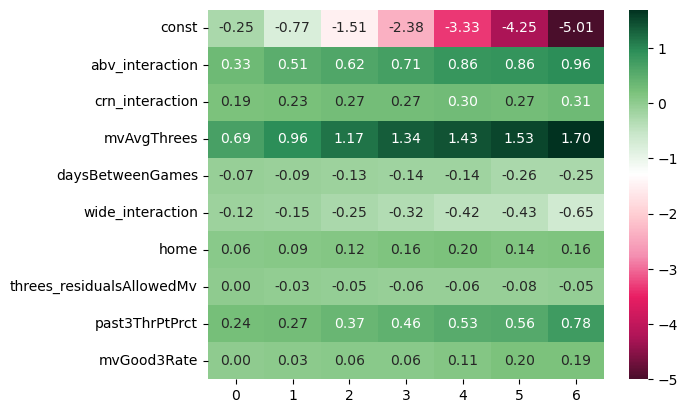

Dropping: abv_interaction
Optimization terminated successfully.
         Current function value: 1.358572
         Iterations: 224
         Function evaluations: 225
         Gradient evaluations: 225
brier score of:  0.660
0.6604157324431498


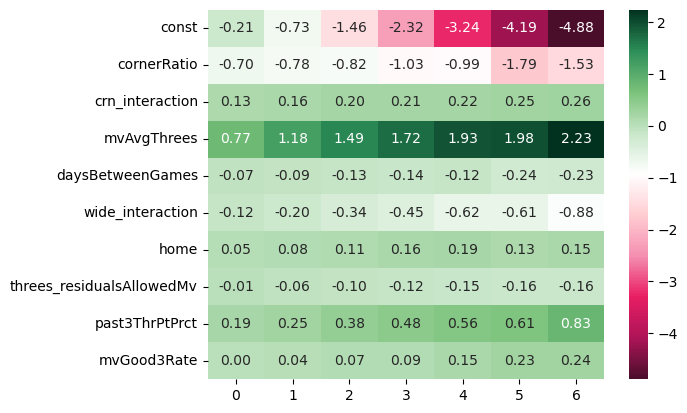

Dropping: crn_interaction
Optimization terminated successfully.
         Current function value: 1.352410
         Iterations: 199
         Function evaluations: 200
         Gradient evaluations: 200
brier score of:  0.658
0.6580636665529733


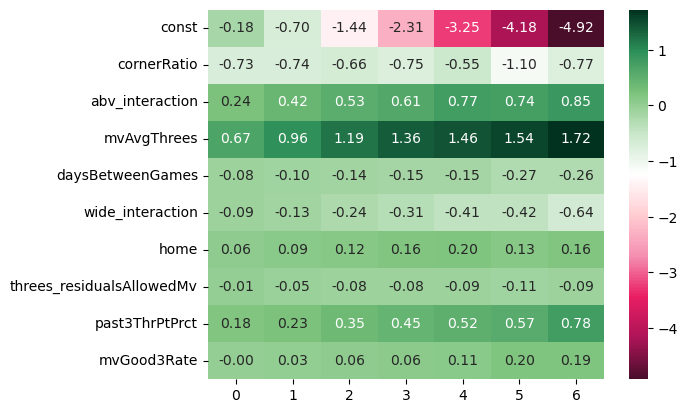

Dropping: mvAvgThrees
Optimization terminated successfully.
         Current function value: 1.374556
         Iterations: 206
         Function evaluations: 207
         Gradient evaluations: 207
brier score of:  0.665
0.6646503713867524


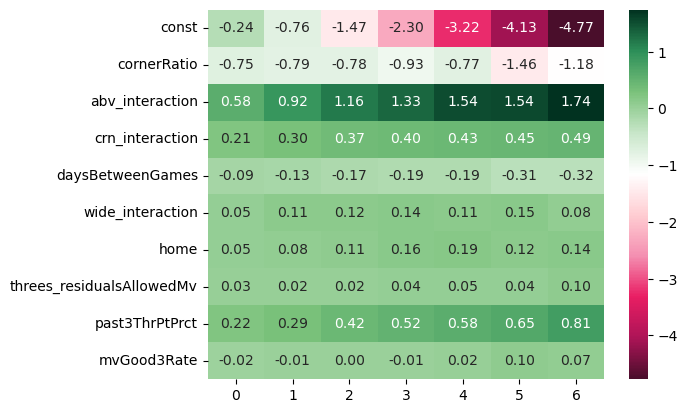

Dropping: daysBetweenGames
Optimization terminated successfully.
         Current function value: 1.351067
         Iterations: 215
         Function evaluations: 216
         Gradient evaluations: 216
brier score of:  0.658
0.6577866317604545


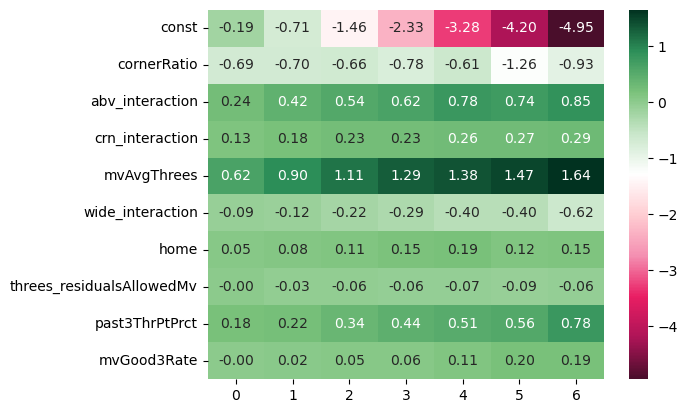

Dropping: wide_interaction
Optimization terminated successfully.
         Current function value: 1.352239
         Iterations: 216
         Function evaluations: 217
         Gradient evaluations: 217
brier score of:  0.658
0.657918435767597


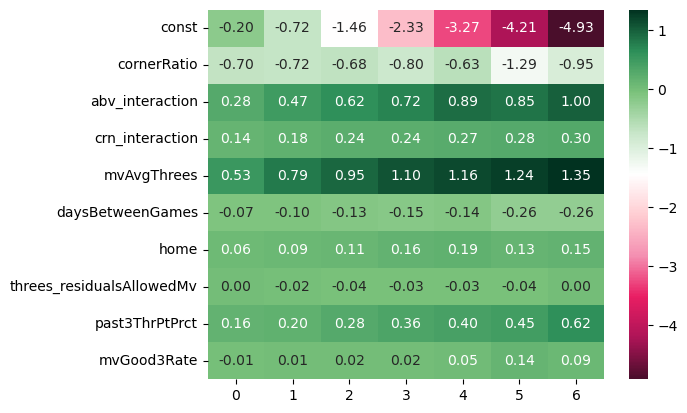

Dropping: home
Optimization terminated successfully.
         Current function value: 1.350286
         Iterations: 197
         Function evaluations: 198
         Gradient evaluations: 198
brier score of:  0.657
0.6572983487652203


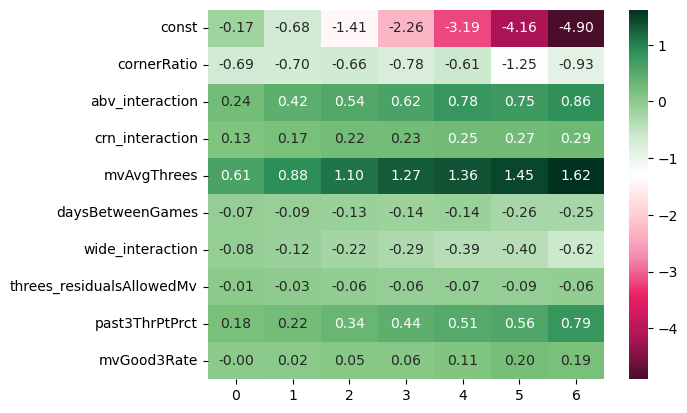

Dropping: crn_fgaMv
Optimization terminated successfully.
         Current function value: 1.350034
         Iterations: 219
         Function evaluations: 220
         Gradient evaluations: 220
brier score of:  0.657
0.6572033984126716


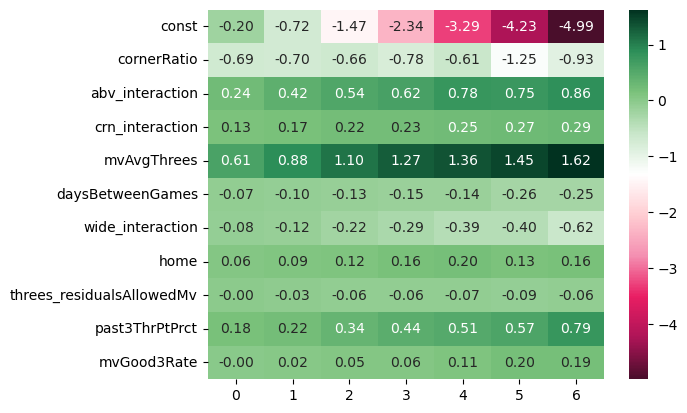

Dropping: abv_fgaMv
Optimization terminated successfully.
         Current function value: 1.350034
         Iterations: 219
         Function evaluations: 220
         Gradient evaluations: 220
brier score of:  0.657
0.6572033984126716


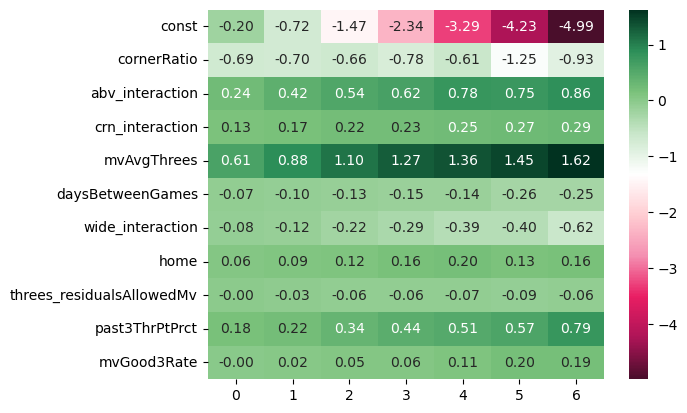

Dropping: threes_residualsAllowedMv
Optimization terminated successfully.
         Current function value: 1.350238
         Iterations: 215
         Function evaluations: 216
         Gradient evaluations: 216
brier score of:  0.657
0.6572152024050106


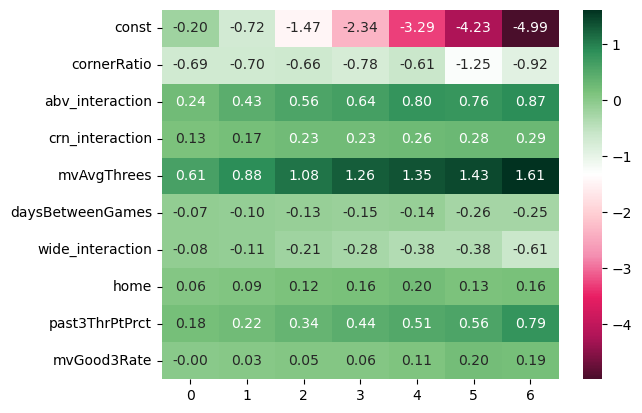

Dropping: past3ThrPtPrct
Optimization terminated successfully.
         Current function value: 1.353479
         Iterations: 205
         Function evaluations: 206
         Gradient evaluations: 206
brier score of:  0.659
0.6589319471170408


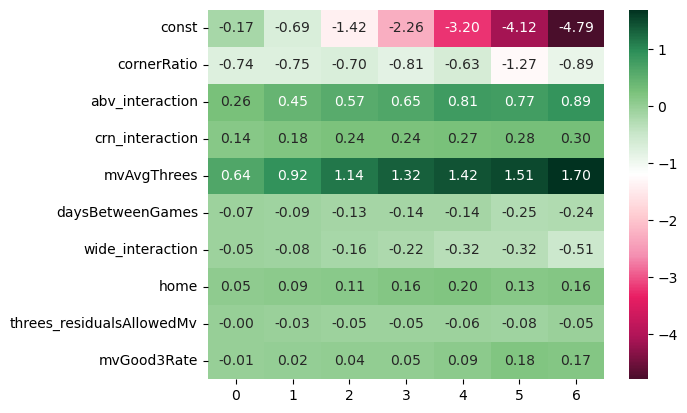

Dropping: mvGood3Rate
Optimization terminated successfully.
         Current function value: 1.350478
         Iterations: 219
         Function evaluations: 220
         Gradient evaluations: 220
brier score of:  0.657
0.6573489753046822


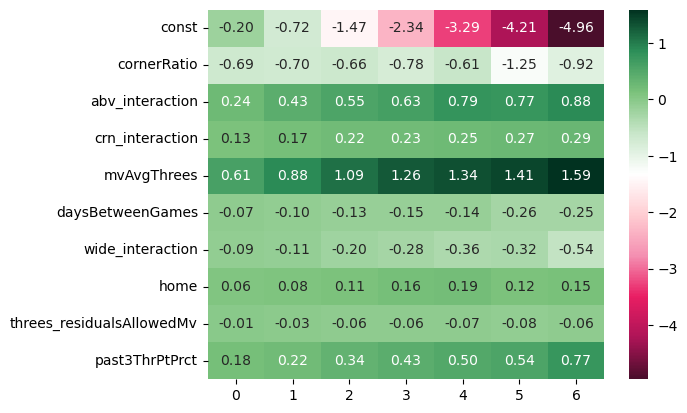

In [693]:
for col in threes.features[1:]:
    print('Dropping:',col)
    mod_run([col,'crn_fgaMv','abv_fgaMv'])
    

Optimization terminated successfully.
         Current function value: 1.400224
         Iterations: 87
         Function evaluations: 89
         Gradient evaluations: 89
brier score of:  0.673
0.6731793611496542
Model Brier: 0.0841
Null Brier: 0.0926
Skill score: 0.0914


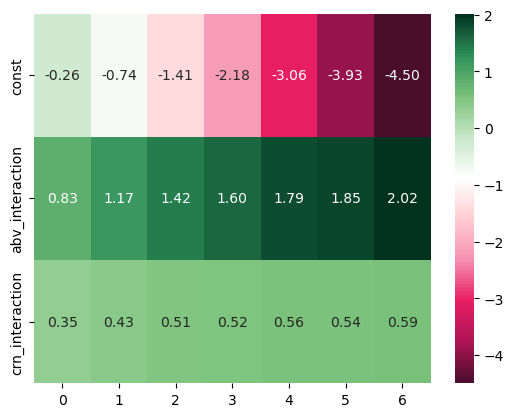

In [701]:
mod_run([c for c in x_test.columns if c not in ['abv_interaction','crn_interaction']])

In [26]:
import requests
import pytz
import time
import sqlite3
import pandas as pd
from datetime import datetime, timedelta


def parse_odds_response(data, snapshot_time, date):
    """
    Flatten the-odds-api response into a DataFrame.
    snapshot_time: '6am' or '4pm'
    date: 'YYYY-MM-DD'
    """
    rows = []
    
    for game in data.get('data', []):
        game_id = game.get('id')
        commence_time = game.get('commence_time')
        home_team = game.get('home_team')
        away_team = game.get('away_team')
        
        for bookmaker in game.get('bookmakers', []):
            book_key = bookmaker.get('key')
            book_update = bookmaker.get('last_update')
            
            for market in bookmaker.get('markets', []):
                market_key = market.get('key')
                
                # group outcomes by player and point
                outcomes_by_player = {}
                for outcome in market.get('outcomes', []):
                    player = outcome.get('description')
                    side = outcome.get('name')
                    price = outcome.get('price')
                    point = outcome.get('point')
                    
                    if player not in outcomes_by_player:
                        outcomes_by_player[player] = {'point': point}
                    outcomes_by_player[player][side.lower()] = price
                
                for player, vals in outcomes_by_player.items():
                    rows.append({
                        'game_date': date,
                        'snapshot_time': snapshot_time,
                        'api_game_id': game_id,
                        'commence_time': commence_time,
                        'home_team': home_team,
                        'away_team': away_team,
                        'bookmaker': book_key,
                        'book_last_update': book_update,
                        'market': market_key,
                        'player': player,
                        'line': vals.get('point'),
                        'over_price': vals.get('over'),
                        'under_price': vals.get('under')
                    })
    
    return pd.DataFrame(rows)


def get_historical_odds(date, api_key, snapshot_time='6am'):
    est = pytz.timezone('US/Eastern')
    hour = 6 if snapshot_time == '6am' else 16
    dt = est.localize(datetime.strptime(
        '{} {:02d}:00:00'.format(date, hour), '%Y-%m-%d %H:%M:%S'))
    date_str = dt.astimezone(pytz.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
    
    url = 'https://api.the-odds-api.com/v4/historical/sports/basketball_nba/odds/'
    params = {
        'apiKey': api_key,
        'regions': 'us',
        'markets': 'player_threes,player_threes_alternate',
        'oddsFormat': 'american',
        'date': date_str,
        'bookmakers': 'fanduel,draftkings,espnbet'
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    remaining = response.headers.get('x-requests-remaining', 'unknown')
    used = response.headers.get('x-requests-used', 'unknown')
    
    return response.json(), remaining, used


def ingest_historical_odds(start_date, end_date, api_key, conn):
    """
    Loop over date range, pull both snapshots, store in database.
    start_date, end_date: 'YYYY-MM-DD'
    conn: sqlite3 connection
    """
    cur = conn.cursor()
    cur.execute('''
        CREATE TABLE IF NOT EXISTS odds_history (
            game_date TEXT,
            snapshot_time TEXT,
            api_game_id TEXT,
            commence_time TEXT,
            home_team TEXT,
            away_team TEXT,
            bookmaker TEXT,
            book_last_update TEXT,
            market TEXT,
            player TEXT,
            line FLOAT,
            over_price FLOAT,
            under_price FLOAT,
            PRIMARY KEY (game_date, snapshot_time, api_game_id, bookmaker, market, player, line)
        )
    ''')
    conn.commit()
    
    current = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    total_requests = 0
    
    while current <= end:
        date_str = current.strftime('%Y-%m-%d')
        
        for snapshot in ['6am', '4pm']:
            try:
                data, remaining, used = get_historical_odds(date_str, api_key, snapshot)
                df = parse_odds_response(data, snapshot, date_str)
                
                if not df.empty:
                    df.to_sql('odds_history', conn, if_exists='append', index=False,
                             method='ignore')
                    conn.commit()
                
                total_requests += 1
                print('{} {} — {} rows | requests used: {} | remaining: {}'.format(
                    date_str, snapshot, len(df), used, remaining))
                
                # respect rate limits
                time.sleep(0.5)
                
            except Exception as e:
                print('Failed {} {}: {}'.format(date_str, snapshot, str(e)))
        
        current += timedelta(days=1)
    
    print('\nDone. Total requests used: {}'.format(total_requests))

In [27]:
etl.showTables

,type,name,tbl_name,rootpage,sql
0,table,rosters,rosters,4,"CREATE TABLE rosters(\n teamId TEXT,\n s..."
1,table,players,players,2,"CREATE TABLE players(\n player_id TEXT,..."
2,table,teams,teams,6,"CREATE TABLE teams(\n team_id TEXT,\n te..."
3,table,plyrLogs,plyrLogs,123,"CREATE TABLE plyrLogs (player_id TEXT,\nteam_i..."
4,view,team_game,team_game,0,"CREATE VIEW team_game as \nSELECT season, game..."
5,table,shotsAllowed,shotsAllowed,582,"CREATE TABLE shotsAllowed (team_id TEXT,\ngame..."
6,view,roster_view,roster_view,0,"CREATE VIEW roster_view AS\nSELECT name, playe..."
7,table,oddsPoints,oddsPoints,761,"CREATE TABLE oddsPoints(\n name TEXT,\n ..."
8,table,oddsThrees,oddsThrees,18683,"CREATE TABLE oddsThrees(\n name TEXT,\n ..."
9,table,oddsFirstBasket,oddsFirstBasket,18685,"CREATE TABLE oddsFirstBasket(\n name TEXT,\..."


In [28]:
pd.read_sql('select max(game_date) from oddsThrees',etl.conn)

,max(game_date)
0,2025-03-27


In [29]:
pd.read_sql("select distinct game_date from teamLog where game_date > '2025-03-27'",etl.conn).values.flatten()

array(['2025-12-23', '2025-12-22', '2025-12-21', '2025-12-20',
       '2025-12-19', '2025-12-18', '2025-12-17', '2025-12-15',
       '2025-12-14', '2025-12-13', '2025-12-12', '2025-12-11',
       '2025-12-10', '2025-12-09', '2025-12-08', '2025-12-07',
       '2025-12-06', '2025-12-05', '2025-12-04', '2025-12-03',
       '2025-12-02', '2025-12-01', '2025-11-30', '2025-11-29',
       '2025-11-28', '2025-11-26', '2025-11-25', '2025-11-24',
       '2025-11-23', '2025-11-22', '2025-11-10', '2025-11-06',
       '2025-11-05', '2025-11-04', '2025-11-03', '2025-11-02',
       '2025-11-01', '2025-10-31', '2025-10-30', '2025-10-29',
       '2025-10-28', '2025-10-27', '2025-10-26', '2025-10-25',
       '2025-10-24', '2025-10-23', '2025-10-22', '2025-10-21',
       '2025-04-13', '2025-04-11', '2025-04-10', '2025-04-09',
       '2025-04-08', '2025-04-07', '2025-04-06', '2025-04-05',
       '2025-04-04', '2025-04-03', '2025-04-02', '2025-04-01',
       '2025-03-31', '2025-03-30', '2025-03-29', '2025-

In [32]:
from betting import funcs

In [33]:
odds = funcs.odds()

'2c48a00da6ae9ef91f8ed17134b75cc5'

In [48]:
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
from nba.run import run_pipeline,data_pull,run_model

etl = NBAetl.etl()
data = NBAdata.data()
from betting import funcs
od = funcs.odds()

In [59]:
pd.read_sql('select min(date) from lines',etl.conn).describe()

,min(date)
count,1
unique,1
top,2024-12-15
freq,1


In [62]:
od.fetch_historical_odds('threes','2023-12-10')

""


In [ ]:
pd.read_sq

In [76]:
games = pd.read_sql("select distinct game_date from teamLog where game_date between'2023-10-25' AND '2024-12-14' ",etl.conn).values.flatten()

In [77]:
l = []
for d in games:
    temp = od.fetch_historical_odds('threes',d)
    temp['date'] = d
    l.append(temp)
    

In [81]:
od.fetch_historical_odds('threes','2025-12-01')

""
